# Phase 2 - K-Means Clustering

## Name: AYUSH KUMAR YADAV
## Registration Number: 23BDS0333
## Dataset: Lithium-Ion Battery Materials

### Objective

The objective of this notebook is to apply K-Means clustering to the
Lithium-Ion Battery Materials dataset.

The numerical material properties are standardized before clustering.
The Elbow Method and Silhouette Score are used to evaluate different
numbers of clusters and determine a suitable cluster count.

The final clusters are visualized in two and three dimensions, and
cluster profiles are generated to understand the characteristics of
different groups of materials.

K-MEANS CLUSTERING

Dataset Shape:
(339, 30)

Variables used for clustering:
['formation_energy_ev', 'e_above_hull_ev', 'band_gap_ev', 'nsites', 'density_gm_cc', 'volume']

Number of observations used:
338

Standardization completed.

ELBOW METHOD


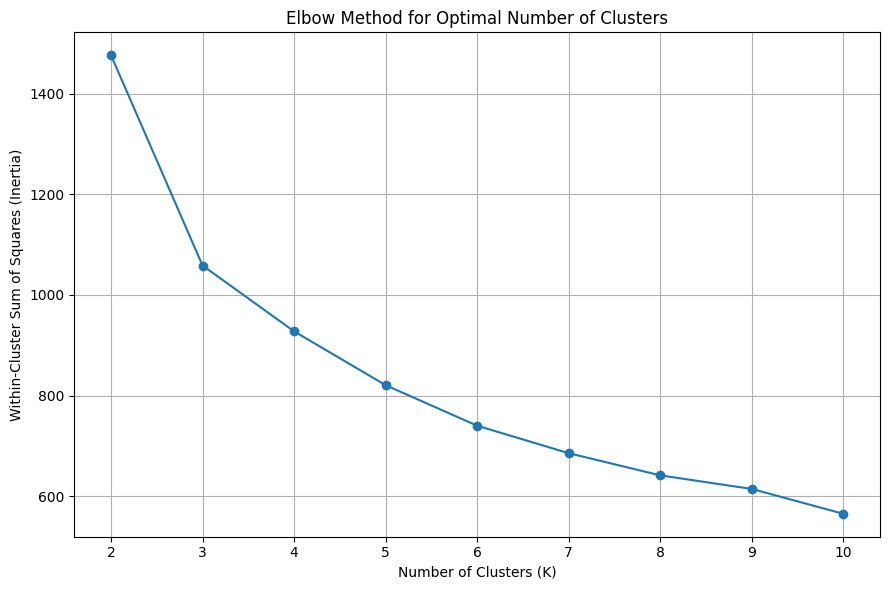


SILHOUETTE SCORE ANALYSIS


,K,Silhouette Score
0,2,0.309226
1,3,0.299549
2,4,0.288811
3,5,0.253886
4,6,0.260482
5,7,0.251153
6,8,0.242599
7,9,0.238320
8,10,0.256700


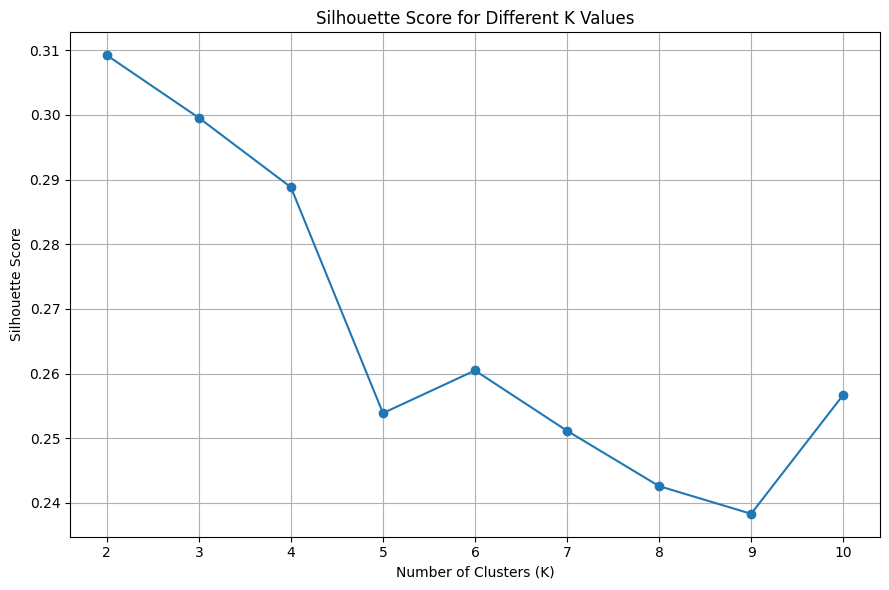


Best K based on Silhouette Score:
2

Best Silhouette Score:
0.3092262023050019

Final K-Means clustering completed.

CLUSTER SIZES


,Number of Materials
Cluster,
0,263
1,75



STANDARDIZED CLUSTER CENTERS


,formation_energy_ev,e_above_hull_ev,band_gap_ev,nsites,density_gm_cc,volume
Cluster,,,,,,
0,0.174330,-0.058642,-0.099670,-0.443953,0.136813,-0.453724
1,-0.611316,0.205639,0.349509,1.556794,-0.479757,1.591058



CLUSTER CENTERS - ORIGINAL SCALE


,formation_energy_ev,e_above_hull_ev,band_gap_ev,nsites,density_gm_cc,volume
Cluster,,,,,,
0,-2.584186,0.05638,1.971990,28.505703,3.033684,334.121506
1,-2.728093,0.06440,2.459653,74.680000,2.816000,930.615320



CLUSTER PROFILE


,formation_energy_ev,e_above_hull_ev,band_gap_ev,nsites,density_gm_cc,volume
Cluster,,,,,,
0,-2.5842,0.0564,1.9720,28.5057,3.0337,334.1215
1,-2.7281,0.0644,2.4597,74.6800,2.8160,930.6153


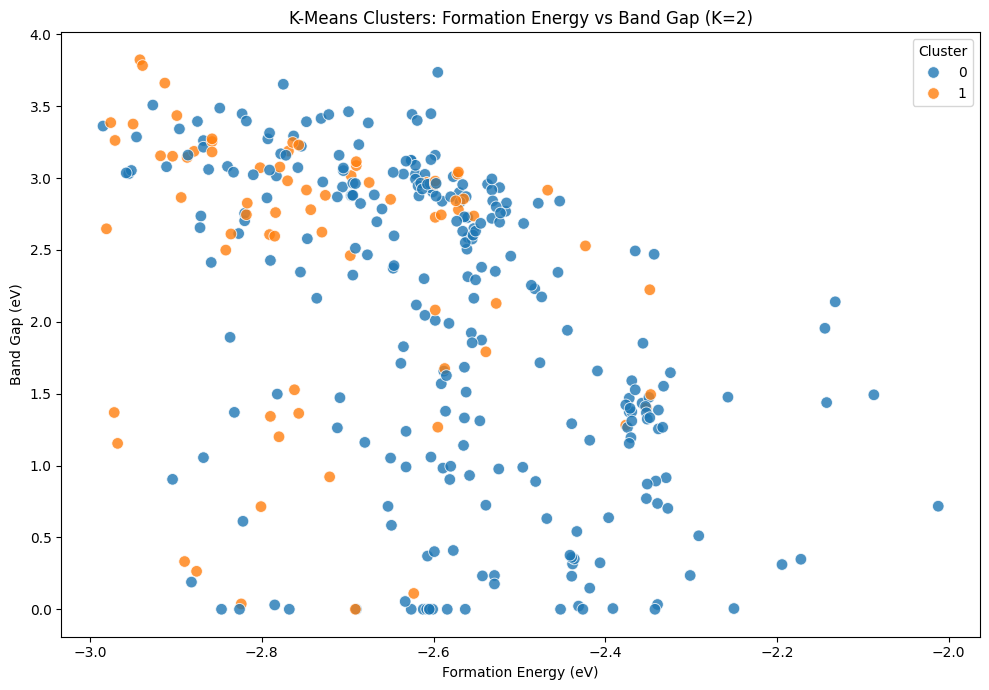

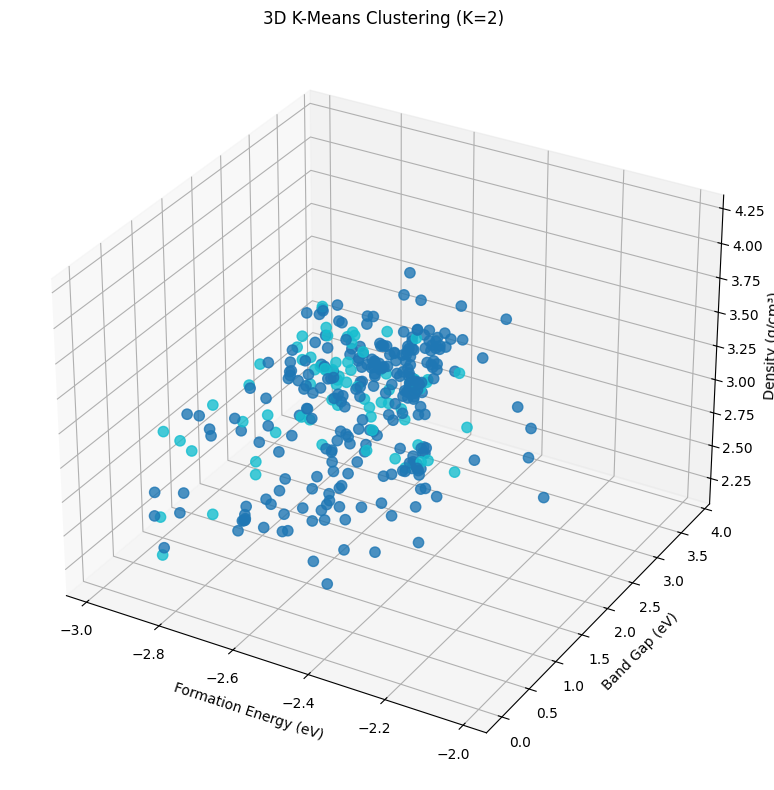

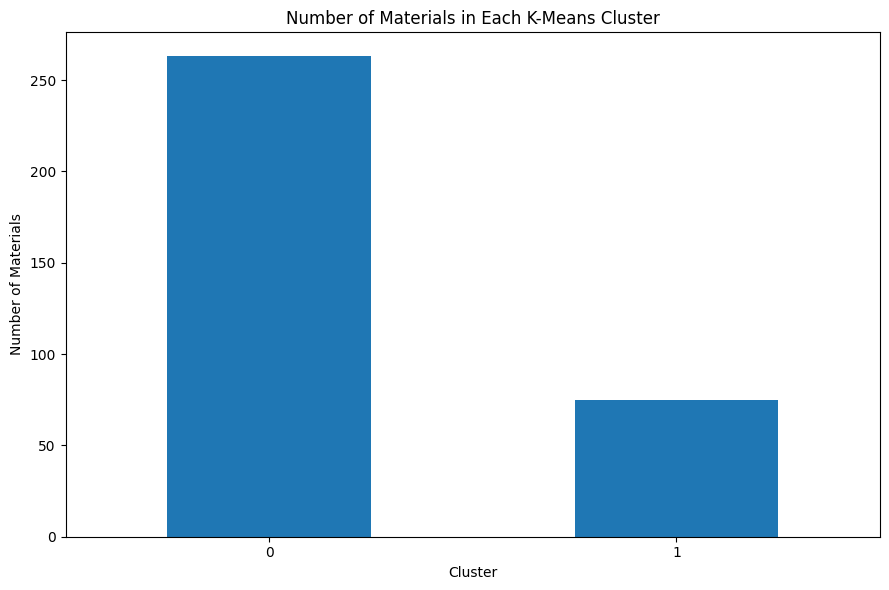

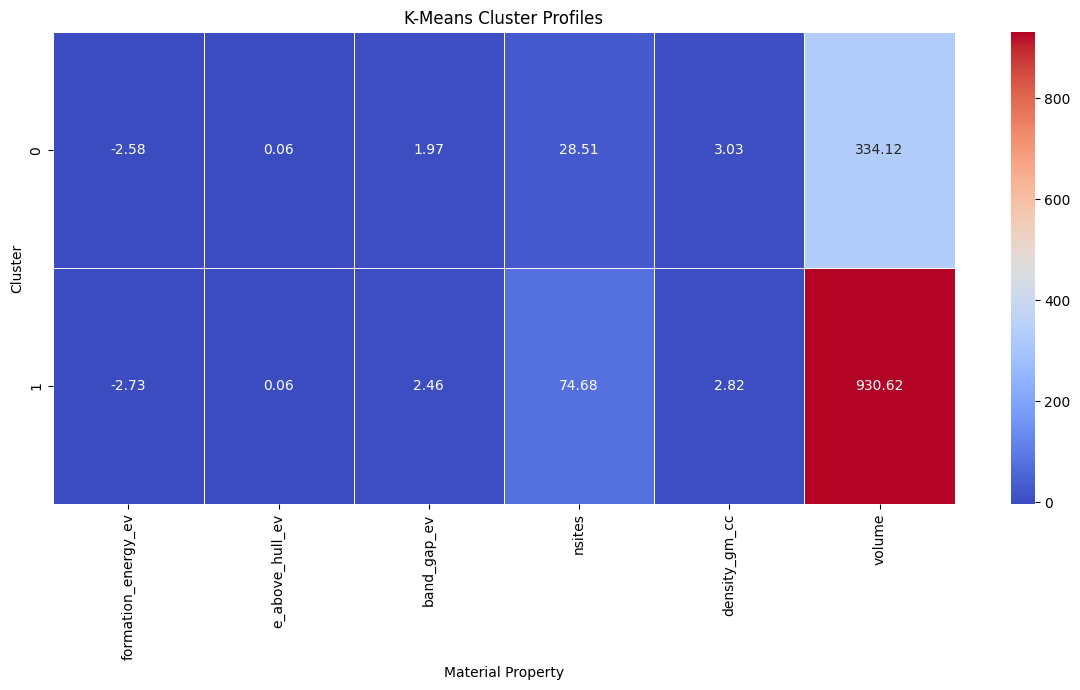


FINAL CLUSTERING PERFORMANCE
Optimal K: 2
Final Silhouette Score: 0.3092262023050019

Clustered dataset saved as:
lithium_ion_kmeans_clustered.csv

K-MEANS CLUSTERING COMPLETED


In [1]:
# ============================================================
# PHASE 2 - K-MEANS CLUSTERING
# Name        : AYUSH KUMAR YADAV
# Registration: 23BDS0333
# Dataset     : Lithium-Ion Battery Materials
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "lithium_ion_transformed.csv"

df = pd.read_csv(file_path)

print("=" * 75)
print("K-MEANS CLUSTERING")
print("=" * 75)

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 2. SELECT CLUSTERING VARIABLES
# ------------------------------------------------------------

clustering_columns = [
    "formation_energy_ev",
    "e_above_hull_ev",
    "band_gap_ev",
    "nsites",
    "density_gm_cc",
    "volume"
]

clustering_columns = [
    column for column in clustering_columns
    if column in df.columns
]

print("\nVariables used for clustering:")
print(clustering_columns)

# ------------------------------------------------------------
# 3. PREPARE DATA
# ------------------------------------------------------------

clustering_data = df[clustering_columns].copy()

# Remove rows with missing values if any
clustering_data = clustering_data.dropna()

print("\nNumber of observations used:")
print(len(clustering_data))

# ------------------------------------------------------------
# 4. STANDARDIZE VARIABLES
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    clustering_data
)

print("\nStandardization completed.")

# ------------------------------------------------------------
# 5. ELBOW METHOD
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("ELBOW METHOD")
print("=" * 75)

inertia_values = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia_values.append(
        kmeans.inertia_
    )

# ============================================================
# VISUALIZATION 1
# ELBOW CURVE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. SILHOUETTE ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SILHOUETTE SCORE ANALYSIS")
print("=" * 75)

silhouette_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_values.append(score)

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_values
})

display(silhouette_results)

# ============================================================
# VISUALIZATION 2
# SILHOUETTE SCORE CURVE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. SELECT BEST K
# ------------------------------------------------------------

best_index = np.argmax(
    silhouette_values
)

best_k = list(k_values)[best_index]

best_silhouette = silhouette_values[
    best_index
]

print("\nBest K based on Silhouette Score:")
print(best_k)

print("\nBest Silhouette Score:")
print(best_silhouette)

# ------------------------------------------------------------
# 8. FINAL K-MEANS MODEL
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    X_scaled
)

# Add cluster labels to original rows used
clustered_df = df.loc[
    clustering_data.index
].copy()

clustered_df["Cluster"] = cluster_labels

print("\nFinal K-Means clustering completed.")

# ------------------------------------------------------------
# 9. CLUSTER SIZES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLUSTER SIZES")
print("=" * 75)

cluster_sizes = (
    clustered_df["Cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_sizes.to_frame(
        "Number of Materials"
    )
)

# ------------------------------------------------------------
# 10. CLUSTER CENTERS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STANDARDIZED CLUSTER CENTERS")
print("=" * 75)

cluster_centers_scaled = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=clustering_columns
)

cluster_centers_scaled.index.name = "Cluster"

display(
    cluster_centers_scaled
)

# ------------------------------------------------------------
# 11. CLUSTER CENTERS IN ORIGINAL SCALE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLUSTER CENTERS - ORIGINAL SCALE")
print("=" * 75)

cluster_centers_original = pd.DataFrame(
    scaler.inverse_transform(
        final_kmeans.cluster_centers_
    ),
    columns=clustering_columns
)

cluster_centers_original.index.name = "Cluster"

display(
    cluster_centers_original
)

# ------------------------------------------------------------
# 12. CLUSTER PROFILE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLUSTER PROFILE")
print("=" * 75)

cluster_profile = (
    clustered_df
    .groupby("Cluster")[clustering_columns]
    .mean()
    .round(4)
)

display(cluster_profile)

# ============================================================
# VISUALIZATION 3
# 2D CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=clustered_df,
    x="formation_energy_ev",
    y="band_gap_ev",
    hue="Cluster",
    palette="tab10",
    s=70,
    alpha=0.8
)

plt.title(
    f"K-Means Clusters: Formation Energy vs Band Gap (K={best_k})"
)

plt.xlabel("Formation Energy (eV)")
plt.ylabel("Band Gap (eV)")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 4
# 3D CLUSTER VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    clustered_df["formation_energy_ev"],
    clustered_df["band_gap_ev"],
    clustered_df["density_gm_cc"],
    c=clustered_df["Cluster"],
    cmap="tab10",
    s=55,
    alpha=0.8
)

ax.set_title(
    f"3D K-Means Clustering (K={best_k})"
)

ax.set_xlabel("Formation Energy (eV)")
ax.set_ylabel("Band Gap (eV)")
ax.set_zlabel("Density (g/cm³)")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 5
# CLUSTER SIZE BAR CHART
# ============================================================

plt.figure(figsize=(9, 6))

cluster_sizes.plot(
    kind="bar"
)

plt.title("Number of Materials in Each K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Materials")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 6
# CLUSTER PROFILE HEATMAP
# ============================================================

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("K-Means Cluster Profiles")
plt.xlabel("Material Property")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. FINAL SILHOUETTE SCORE
# ------------------------------------------------------------

final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\n" + "=" * 75)
print("FINAL CLUSTERING PERFORMANCE")
print("=" * 75)

print("Optimal K:", best_k)
print("Final Silhouette Score:", final_silhouette)

# ------------------------------------------------------------
# 14. SAVE CLUSTERED DATASET
# ------------------------------------------------------------

output_file = "lithium_ion_kmeans_clustered.csv"

clustered_df.to_csv(
    output_file,
    index=False
)

print("\nClustered dataset saved as:")
print(output_file)

print("\n" + "=" * 75)
print("K-MEANS CLUSTERING COMPLETED")
print("=" * 75)

# Conclusion

K-Means clustering was successfully applied to the Lithium-Ion Battery
Materials dataset.

The numerical material properties were standardized before clustering.
The Elbow Method was used to examine the within-cluster variation, while
Silhouette Scores were calculated for different numbers of clusters.

The number of clusters with the highest Silhouette Score was selected for
the final K-Means model. Cluster sizes, cluster centers, and cluster
profiles were then analyzed.

Two-dimensional and three-dimensional visualizations were used to examine
the separation of the resulting material groups. A cluster-profile heatmap
was also generated to compare the characteristics of different clusters.

The final clustered dataset was saved as
`lithium_ion_kmeans_clustered.csv`.